<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/Scratchpad_bo_or_not_mine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
pip install fiftyone==1.8.0

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
import os
from google.colab import userdata
import kagglehub

# This is set up as an environment variable, it's alive in memory
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# to download the data, we specify the name of the user who published it and the name of the dataset
download_path = kagglehub.dataset_download('andandand/presidential-dog')

Using Colab cache for faster access to the 'presidential-dog' dataset.


In [ ]:
download_path

'/kaggle/input/presidential-dog'

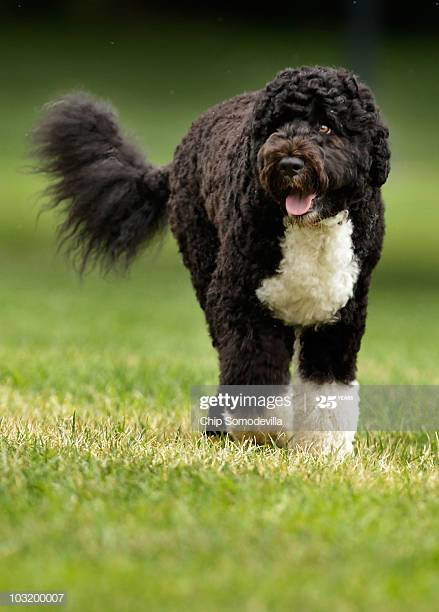

In [ ]:
from PIL import Image
pil_imag = Image.open('/kaggle/input/presidential-dog/presidential_dog/test/bo/bo_20.jpg')
pil_imag

In [ ]:
from torchvision.models import VGG16_Weights
pretrained_weights = VGG16_Weights.IMAGENET1K_V1
dir(pretrained_weights)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [ ]:
original_transformation = pretrained_weights.transforms()
original_transformation

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
imag_tensor_imagenet_scaled = original_transformation(pil_imag)
imag_tensor_imagenet_scaled.shape

torch.Size([3, 224, 224])

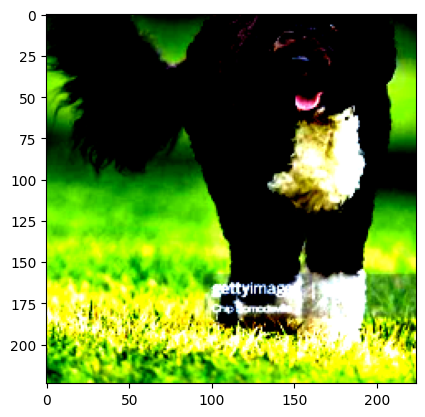

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(imag_tensor_imagenet_scaled.permute(1, 2, 0))

In [ ]:
pretrained_weights.meta

{'min_size': (32, 32),
 'categories': ['tench',
  'goldfish',
  'great white shark',
  'tiger shark',
  'hammerhead',
  'electric ray',
  'stingray',
  'cock',
  'hen',
  'ostrich',
  'brambling',
  'goldfinch',
  'house finch',
  'junco',
  'indigo bunting',
  'robin',
  'bulbul',
  'jay',
  'magpie',
  'chickadee',
  'water ouzel',
  'kite',
  'bald eagle',
  'vulture',
  'great grey owl',
  'European fire salamander',
  'common newt',
  'eft',
  'spotted salamander',
  'axolotl',
  'bullfrog',
  'tree frog',
  'tailed frog',
  'loggerhead',
  'leatherback turtle',
  'mud turtle',
  'terrapin',
  'box turtle',
  'banded gecko',
  'common iguana',
  'American chameleon',
  'whiptail',
  'agama',
  'frilled lizard',
  'alligator lizard',
  'Gila monster',
  'green lizard',
  'African chameleon',
  'Komodo dragon',
  'African crocodile',
  'American alligator',
  'triceratops',
  'thunder snake',
  'ringneck snake',
  'hognose snake',
  'green snake',
  'king snake',
  'garter snake',
 

In [ ]:
from torchvision.models import vgg16, VGG16_Weights

# Loading a pre-trained VGG16 model
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model.eval()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 69.8MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Here we inspect the first layer of features
first_layer = model.features[0]
first_layer

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [ ]:
first_layer.weight

Parameter containing:
tensor([[[[-5.5373e-01,  1.4270e-01,  5.2896e-01],
          [-5.8312e-01,  3.5655e-01,  7.6566e-01],
          [-6.9022e-01, -4.8019e-02,  4.8409e-01]],

         [[ 1.7548e-01,  9.8630e-03, -8.1413e-02],
          [ 4.4089e-02, -7.0323e-02, -2.6035e-01],
          [ 1.3239e-01, -1.7279e-01, -1.3226e-01]],

         [[ 3.1303e-01, -1.6591e-01, -4.2752e-01],
          [ 4.7519e-01, -8.2677e-02, -4.8700e-01],
          [ 6.3203e-01,  1.9308e-02, -2.7753e-01]]],


        [[[ 2.3254e-01,  1.2666e-01,  1.8605e-01],
          [-4.2805e-01, -2.4349e-01,  2.4628e-01],
          [-2.5066e-01,  1.4177e-01, -5.4864e-03]],

         [[-1.4076e-01, -2.1903e-01,  1.5041e-01],
          [-8.4127e-01, -3.5176e-01,  5.6398e-01],
          [-2.4194e-01,  5.1928e-01,  5.3915e-01]],

         [[-3.1432e-01, -3.7048e-01, -1.3094e-01],
          [-4.7144e-01, -1.5503e-01,  3.4589e-01],
          [ 5.4384e-02,  5.8683e-01,  4.9580e-01]]],


        [[[ 1.7715e-01,  5.2149e-01,  9.8740

In [ ]:
# Why doesn't this work?
#first_layer(pil_imag)
output_first_convolutions = first_layer(imag_tensor_imagenet_scaled)
output_first_convolutions.shape

torch.Size([64, 224, 224])

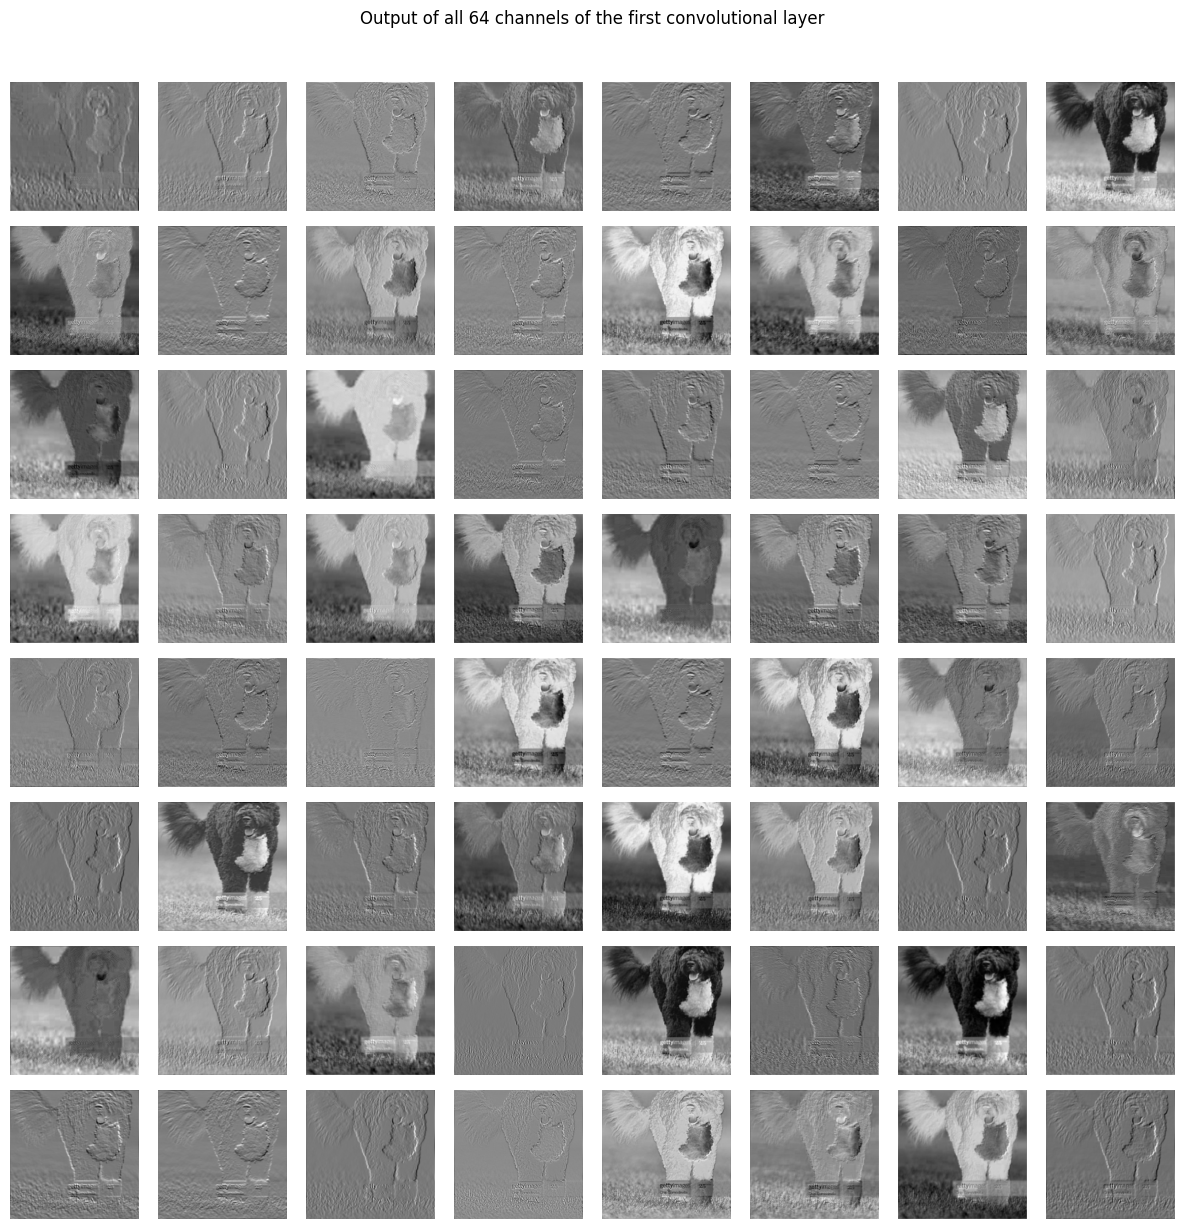

In [ ]:
num_channels = output_first_convolutions.shape[0]
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i in range(num_channels):
    row = i // 8
    col = i % 8
    axes[row, col].imshow(output_first_convolutions[i, :, :].detach().numpy(), cmap='gray')
    axes[row, col].axis('off')

plt.suptitle('Output of all 64 channels of the first convolutional layer', y=1.02)
plt.tight_layout()
plt.show()

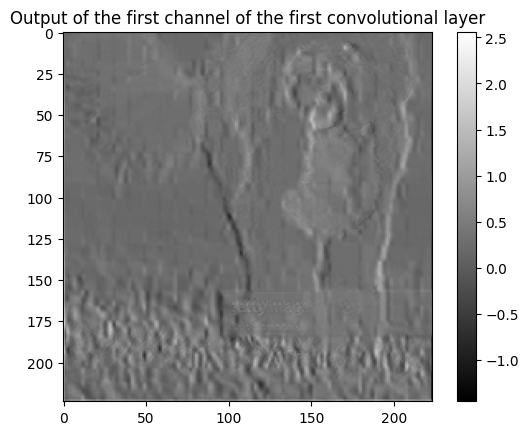

In [ ]:
plt.imshow(output_first_convolutions[0, :, :].detach().numpy(), cmap='gray')
plt.title('Output of the first channel of the first convolutional layer')
plt.colorbar()
plt.show()

## Run image into the full convolutional base of the model

In [ ]:
# Why do we specify singleton dimensions?
# When training, we want to specify the batch size
# which is the number of samples that we show to the model before computing the loss
# and updating the weights (during training)
imag_tensor_imagenet_scaled.unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [ ]:
imag_tensor_imagenet_scaled.unsqueeze(0).squeeze().shape

torch.Size([3, 224, 224])

In [ ]:
output_conv_base = model.features(imag_tensor_imagenet_scaled)
output_conv_base.shape

torch.Size([512, 7, 7])

## Intuition on Class Activation Mapping

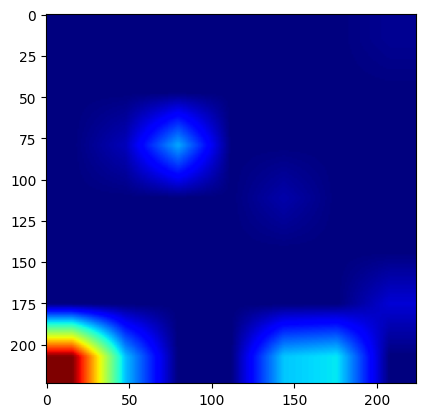

In [ ]:
import torchvision.transforms.v2 as transforms
resize = transforms.Resize(224)
resized_output_conv_base = resize(output_conv_base)
plt.imshow(resized_output_conv_base[0, :, :].detach().numpy(),cmap='jet');

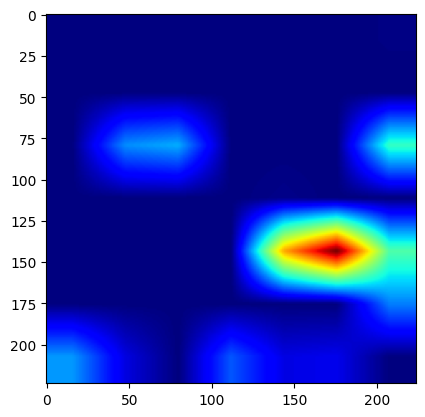

In [ ]:
# For the neural network, the weighted sum comes from the weights of the final layer
weighted_sum = resized_output_conv_base[0, :, :] * .2 + resized_output_conv_base[1, :, :] * .7
plt.imshow(weighted_sum.detach(), cmap='jet');

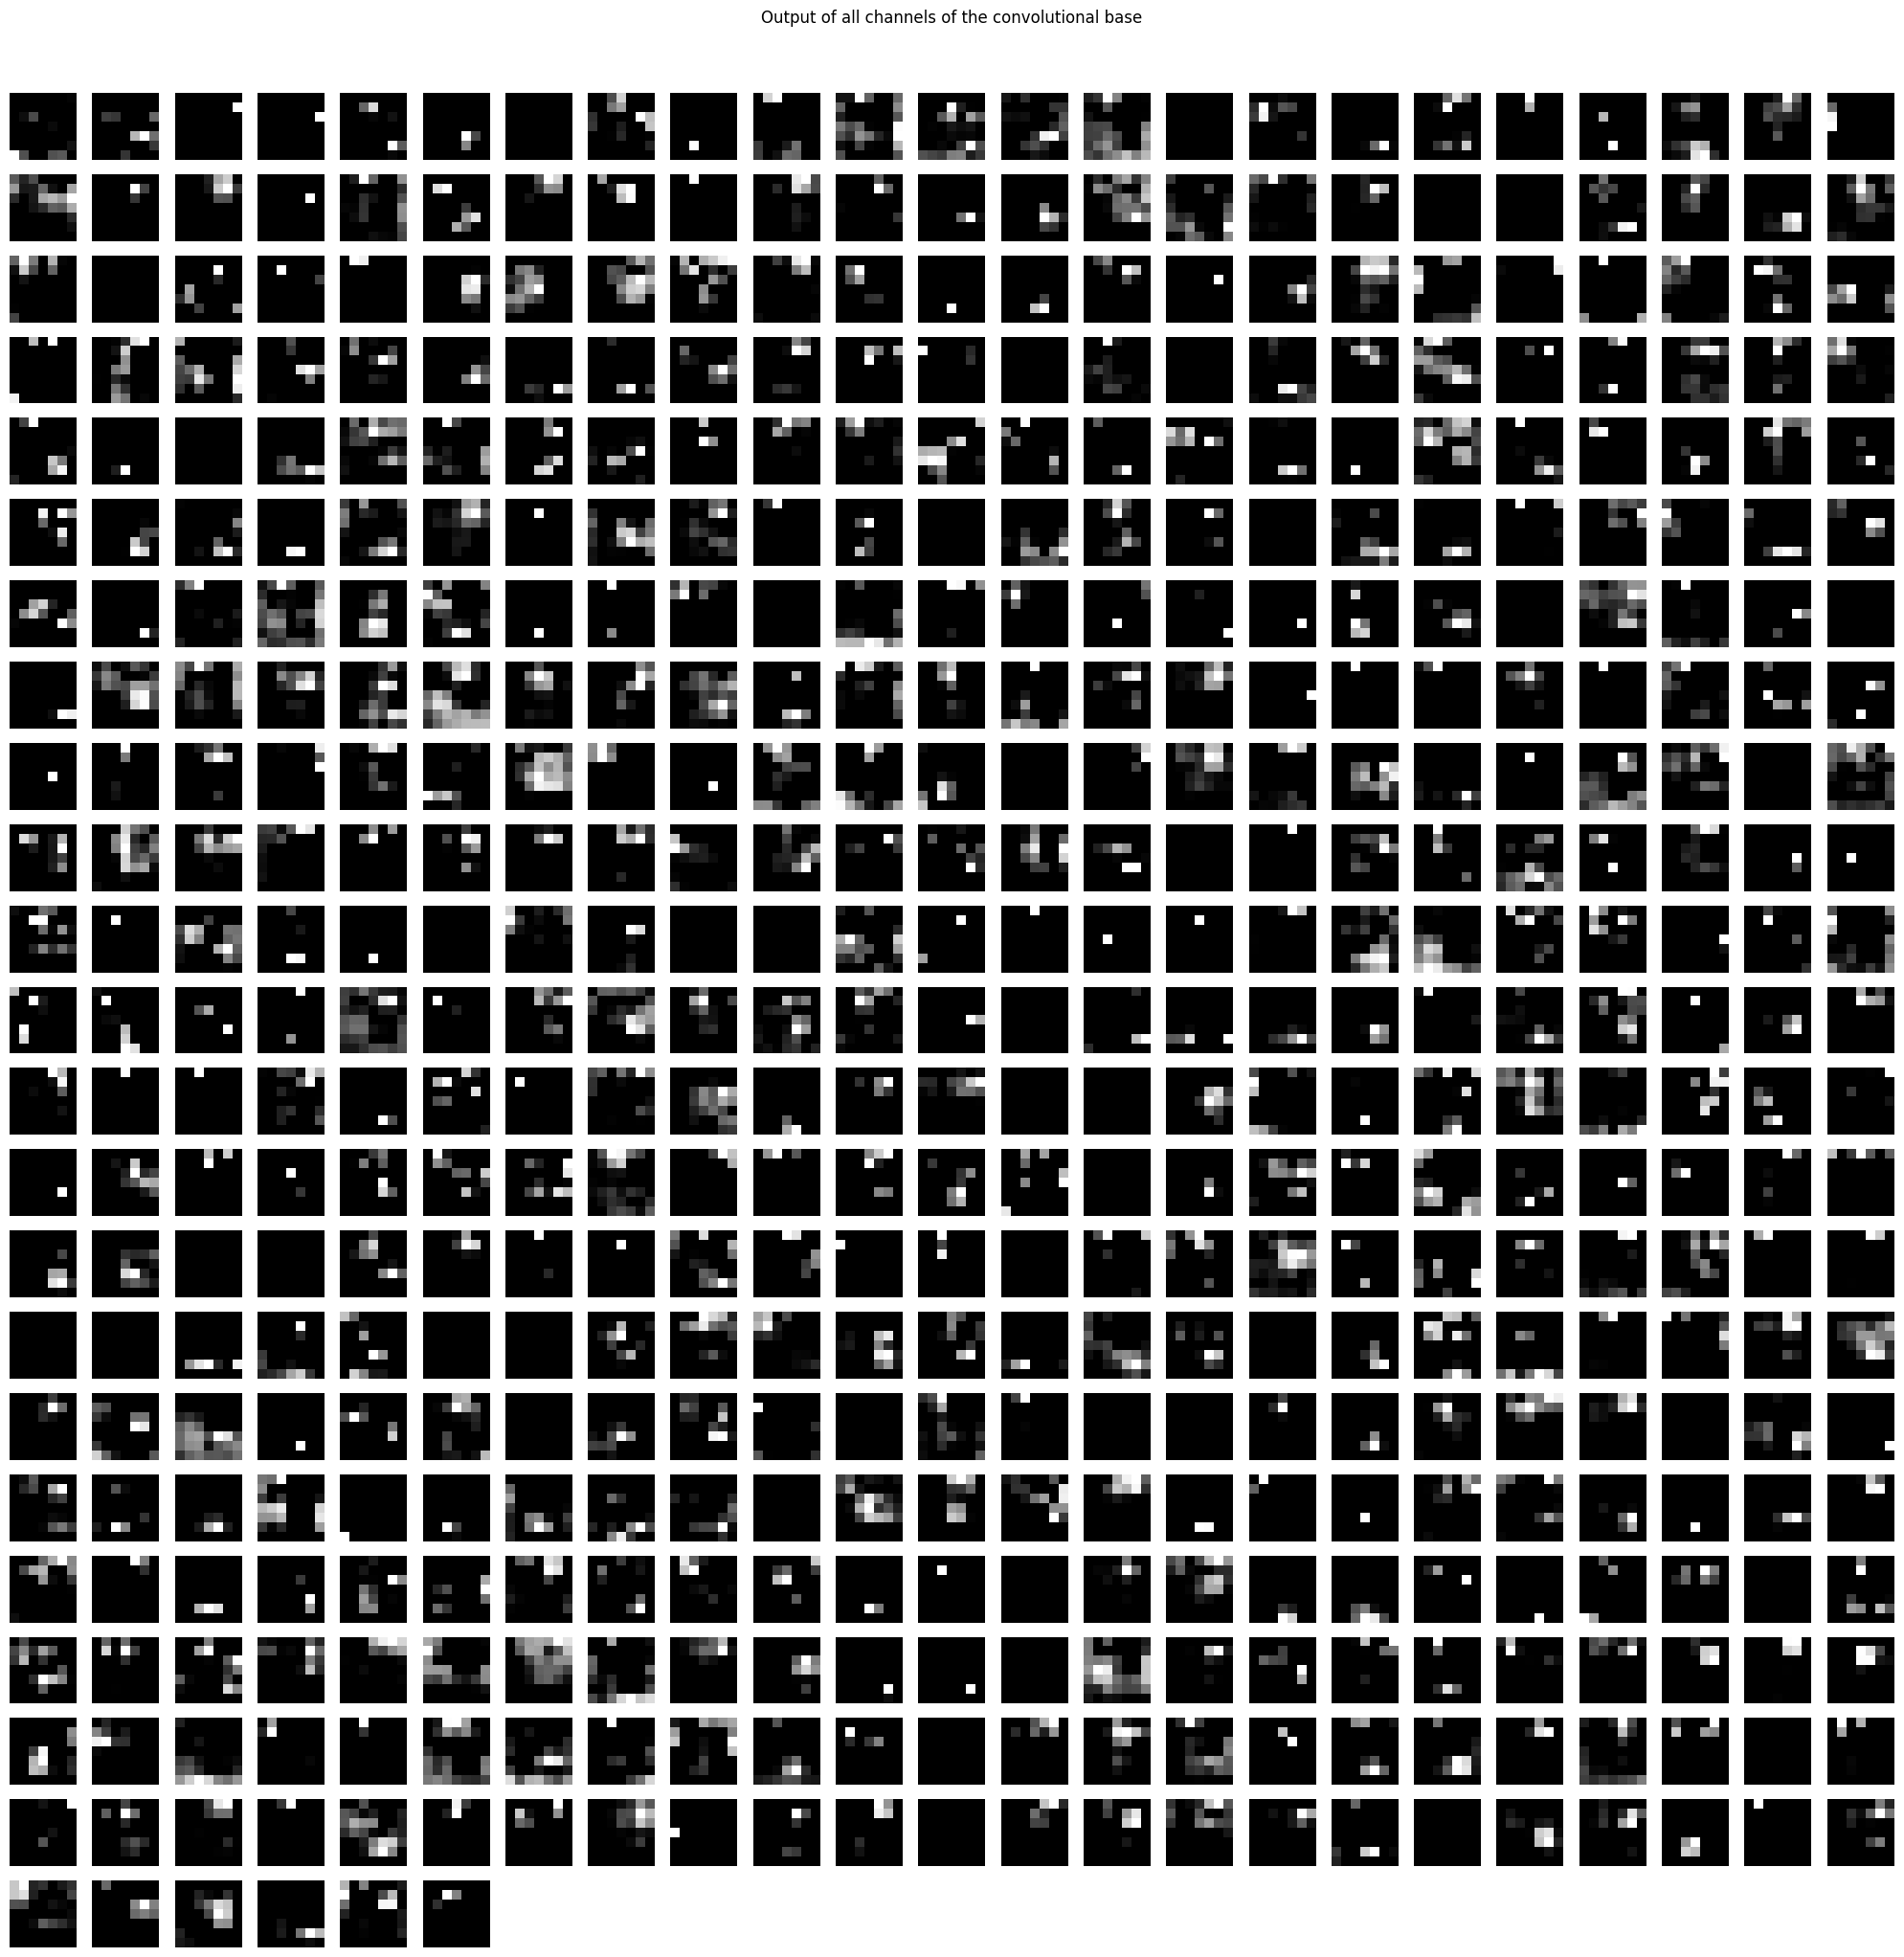

In [ ]:
num_channels_conv_base = output_conv_base.shape[0]
# Determine the grind size, aiming for a roughly square layout
grid_size = int(num_channels_conv_base**0.5) + 1
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))

for i in range(num_channels_conv_base):
    row = i // grid_size
    col = i % grid_size
    axes[row, col].imshow(output_conv_base[i, :, :].detach().numpy(), cmap='gray')
    axes[row, col].axis('off')

# Turn off any unused subplots
for j in range(num_channels_conv_base, grid_size * grid_size):
    row = j // grid_size
    col = j % grid_size
    axes[row, col].axis('off')

plt.suptitle('Output of all channels of the convolutional base', y=1.02)
plt.tight_layout()
plt.show()

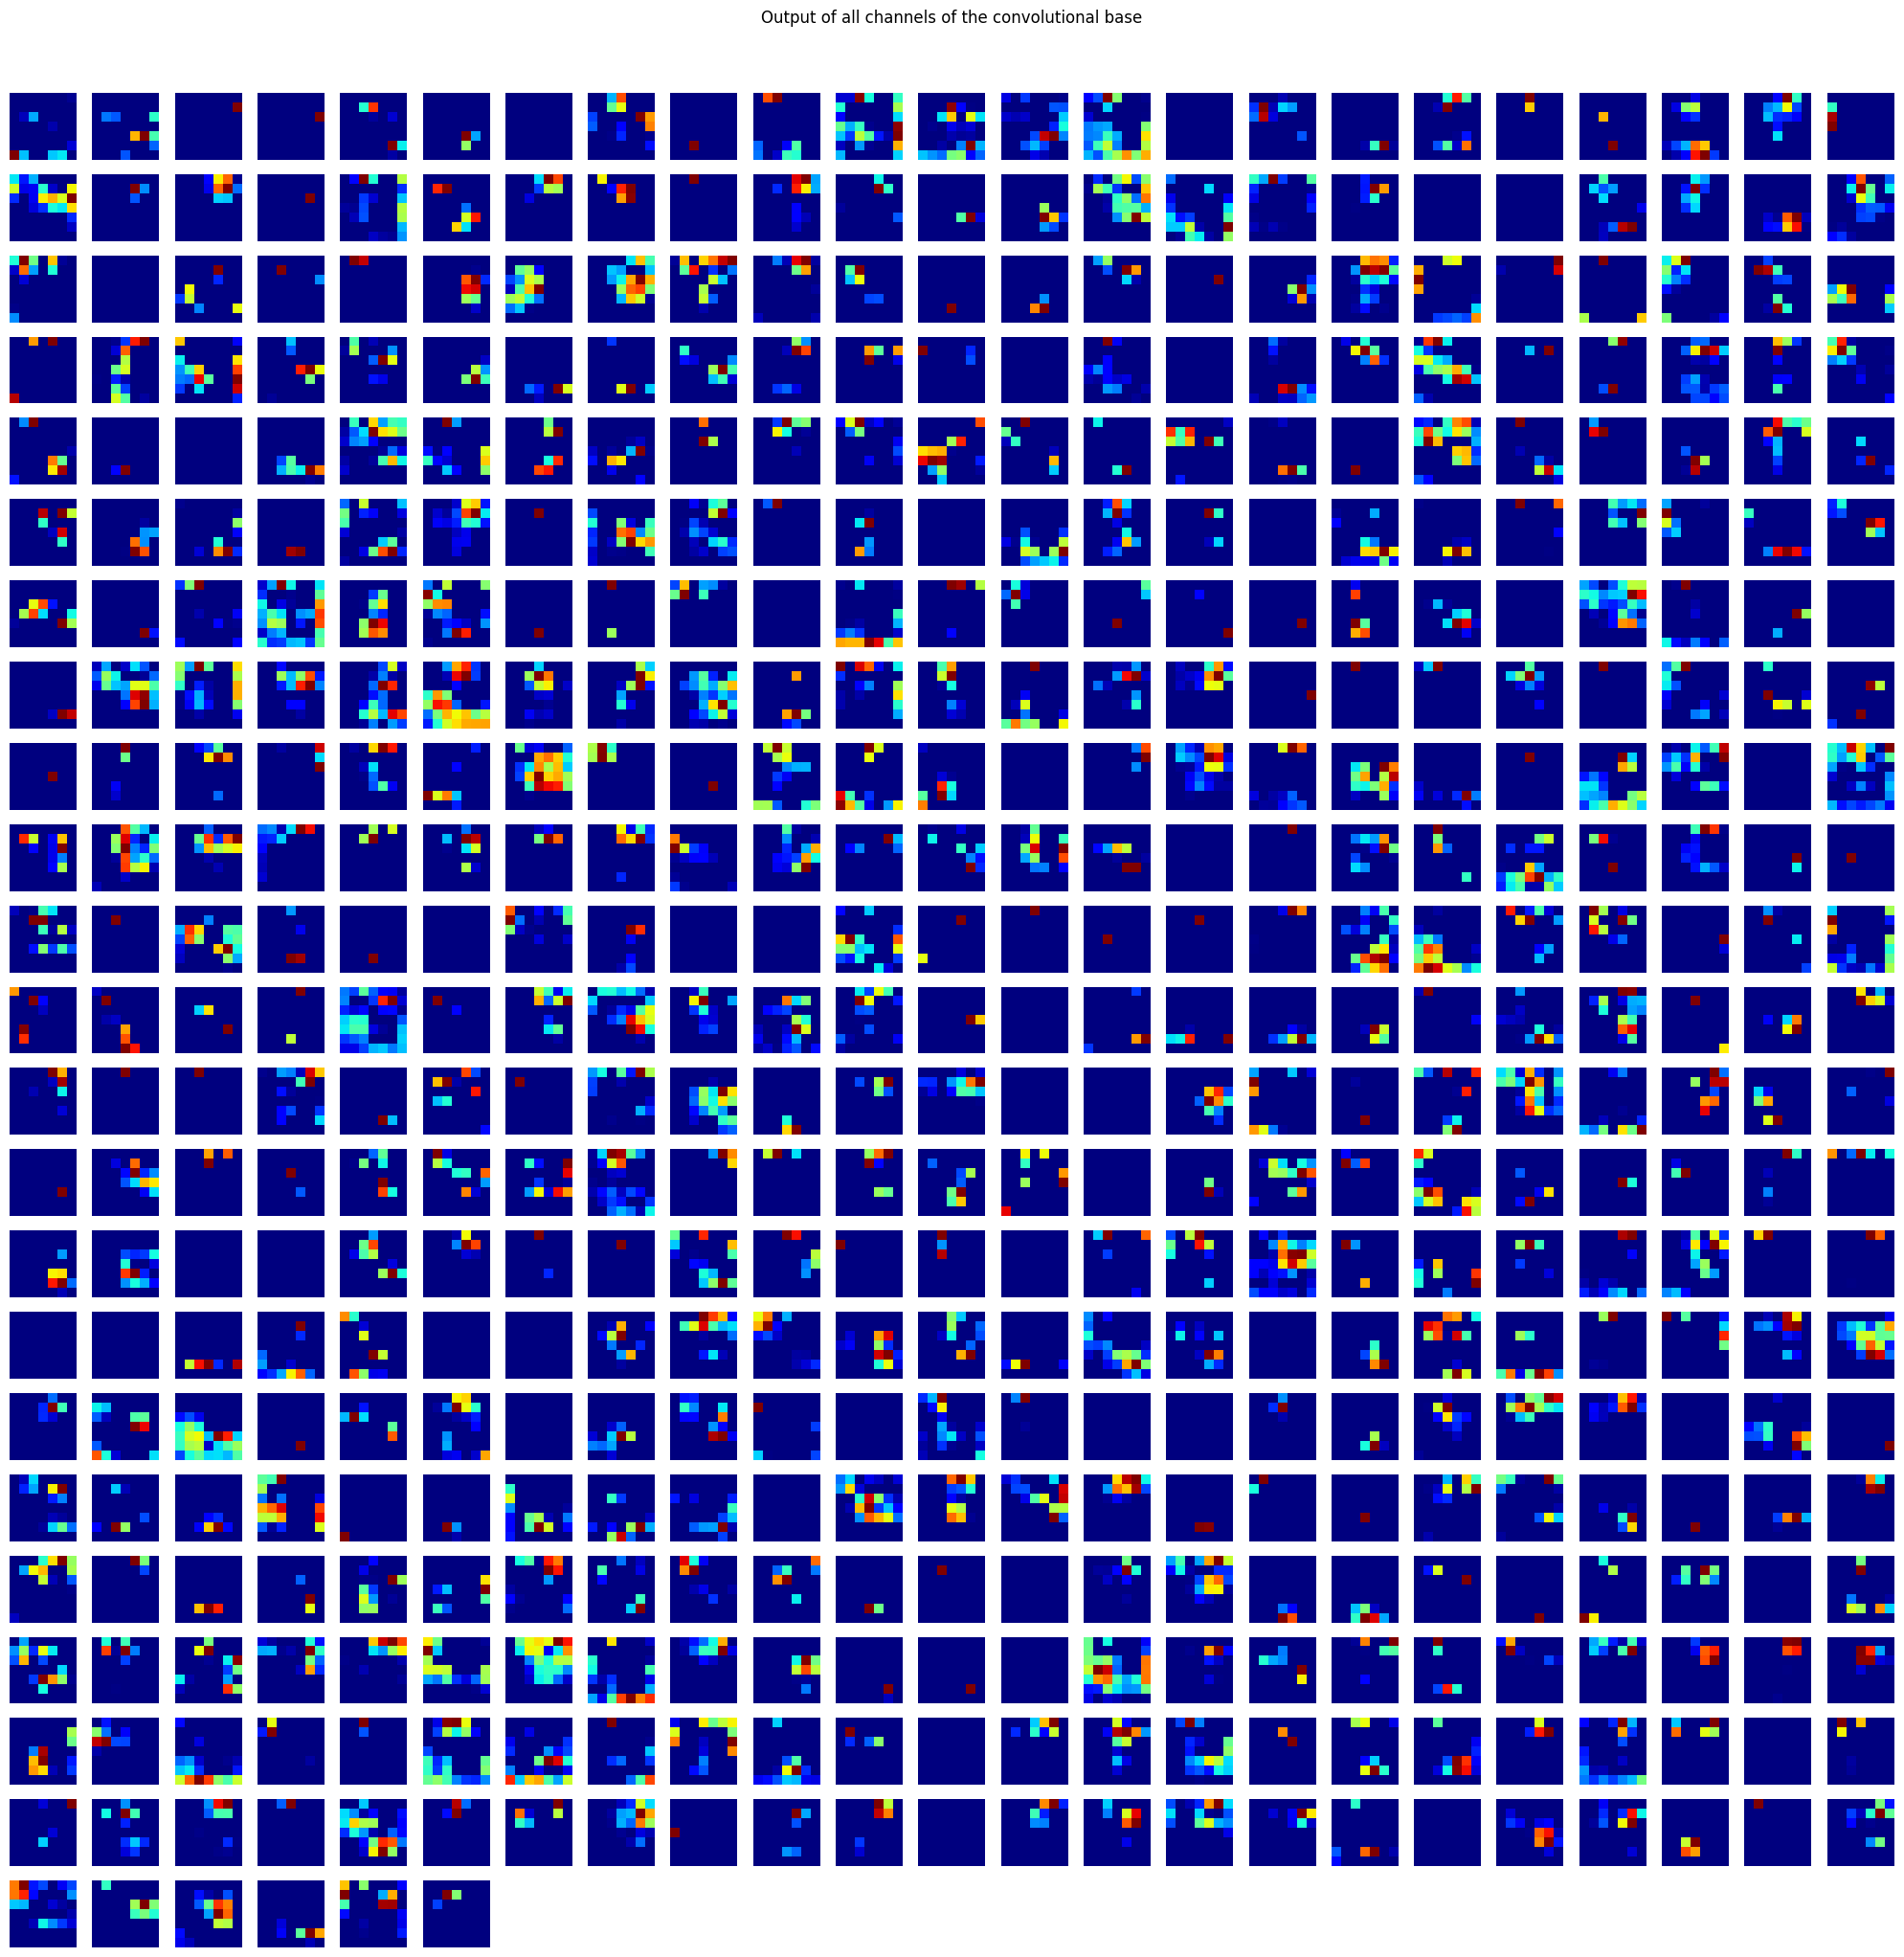

In [ ]:
num_channels_conv_base = output_conv_base.shape[0]
# Determine the grid size, aiming for a roughly square layout
grid_size = int(num_channels_conv_base**0.5) + 1
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))
for i in range(num_channels_conv_base):
    row = i // grid_size
    col = i % grid_size
    axes[row, col].imshow(output_conv_base[i, :, :].detach().numpy(), cmap='jet')
    axes[row, col].axis('off')

# Turn off any unused subplots
for j in range(num_channels_conv_base, grid_size * grid_size):
    row = j // grid_size
    col = j % grid_size
    axes[row, col].axis('off')


plt.suptitle('Output of all channels of the convolutional base', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
model.avgpool

AdaptiveAvgPool2d(output_size=(7, 7))

In [ ]:
import torch.nn as nn
avg_pool_flattening = nn. AdaptiveAvgPool2d(output_size=(1, 1))

In [ ]:
output_conv_base

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0316],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0890, 0.5019,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.1310],
         [1.7209, 0.5398, 0.0000,  ..., 0.5518, 0.6097, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.4473, 0.3875,  ..., 0.0000, 0.0000, 0.7389],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 1.3101, 1.8240, 0.7972],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.4096],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.7917],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.

In [ ]:
output_gap = model.avgpool(output_conv_base)
output_gap.shape

torch.Size([512, 7, 7])

In [ ]:
average_per_filter = avg_pool_flattening(output_conv_base)
average_per_filter.shape

torch.Size([512, 1, 1])

In [ ]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
7 * 7 * 512

25088

In [ ]:
from torchvision.models import resnet18

resnet_model = resnet18()
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Create a FiftyOne dataset

In [ ]:
from pathlib import Path
train_data_path = Path('/kaggle/input/presidential-dog/presidential_dog/train')
test_data_path = Path('/kaggle/input/presidential-dog/presidential_dog/test')
train_data_path, test_data_path

(PosixPath('/kaggle/input/presidential-dog/presidential_dog/train'),
 PosixPath('/kaggle/input/presidential-dog/presidential_dog/test'))

In [ ]:
import fiftyone as fo

# Replace 'dataset_name' with the actual name of the dataset you want to delete
dataset_name = 'bo-training-dataset'

if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)
    print(f"Dataset '{dataset_name}' deleted successfully.")

print(f'Created {dataset_name}')

training_dataset = fo.Dataset.from_dir(
    dataset_dir = str(train_data_path),
    dataset_type = fo.types.ImageClassificationDirectoryTree,
    name=dataset_name
)
import fiftyone.utils.random as four
# split the training_dataset into train and validation
four.random_split(training_dataset,
                  {'train': 0.75, 'validation':0.25},
                  seed=51)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information


Created bo-training-dataset
 100% |█████████████████| 142/142 [97.0ms elapsed, 0s remaining, 1.5K samples/s]   


INFO:eta.core.utils: 100% |█████████████████| 142/142 [97.0ms elapsed, 0s remaining, 1.5K samples/s]   


In [ ]:
training_dataset.count_sample_tags()

{'train': 106, 'validation': 36}

In [ ]:
training_dataset

Name:        bo-training-dataset
Media type:  image
Num samples: 142
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)

In [ ]:
testing_dataset = fo.Dataset.from_dir(
    dataset_dir = str(test_data_path),
    dataset_type = fo.types.ImageClassificationDirectoryTree,
    name='bo-testing-dataset'
)

 100% |███████████████████| 30/30 [28.6ms elapsed, 0s remaining, 1.0K samples/s]      


INFO:eta.core.utils: 100% |███████████████████| 30/30 [28.6ms elapsed, 0s remaining, 1.0K samples/s]      


In [ ]:
testing_dataset.tag_samples('test')

In [ ]:
# merge train and test datasets
import fiftyone as fo

# Replace 'dataset_name' with the actual name of the dataset you want to delete
dataset_name = 'bo-dataset'

if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)
    print(f"Dataset '{dataset_name}' deleted successfully.")

print(f'Created {dataset_name}')
bo_dataset =fo.Dataset(dataset_name)
bo_dataset.merge_samples(training_dataset)
bo_dataset.merge_samples(testing_dataset)

Created bo-dataset


In [ ]:
bo_dataset

Name:        bo-dataset
Media type:  image
Num samples: 172
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)

In [ ]:
bo_dataset.count_sample_tags()

{'train': 106, 'test': 30, 'validation': 36}

In [ ]:
# compute the metadata for the whole dataset
bo_dataset.compute_metadata()

Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████████| 172/172 [402.1ms elapsed, 0s remaining, 427.8 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [402.1ms elapsed, 0s remaining, 427.8 samples/s]      


In [ ]:
session = fo.launch_app(bo_dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.



Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.0

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



INFO:fiftyone.core.session.session:
Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.0

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



https://5151-gpu-t4-s-3iz5cf7onsgc9-b.us-west1-1.prod.colab.dev?polling=true


In [ ]:
session.refresh()
print(session.url)

https://5151-gpu-t4-s-3iz5cf7onsgc9-b.us-west1-1.prod.colab.dev?polling=true


## Load the VGG16 model into FiftyOne

In [ ]:
import fiftyone.zoo as foz

fo_model = foz.load_zoo_model('vgg16-imagenet-torch')
fo_model

INFO:fiftyone.core.models:Downloading model from 'https://download.pytorch.org/models/vgg16-397923af.pth'...


 100% |██████|    4.1Gb/4.1Gb [2.0s elapsed, 0s remaining, 1.9Gb/s]         


INFO:eta.core.utils: 100% |██████|    4.1Gb/4.1Gb [2.0s elapsed, 0s remaining, 1.9Gb/s]         


In [ ]:
fo_model._model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Compute embeddings

In [ ]:
bo_dataset.compute_embeddings(model=fo_model,
                              embeddings_field='vgg16-imagenet-embeddings')

 100% |█████████████████| 172/172 [10.7s elapsed, 0s remaining, 15.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [10.7s elapsed, 0s remaining, 15.9 samples/s]      


In [ ]:
embeddings = bo_dataset.values('vgg16-imagenet-embeddings')
embeddings[0].shape

(4096,)

In [ ]:
len(embeddings)

172

In [ ]:
import fiftyone.brain as fob

pca_visualization = fob.compute_visualization(bo_dataset,
                                                method='pca',
                                                brain_key='vgg_pca')

INFO:fiftyone.core.models:Downloading model from 'https://download.pytorch.org/models/mobilenet_v2-b0353104.pth'...


 100% |████|  108.4Mb/108.4Mb [78.4ms elapsed, 0s remaining, 1.4Gb/s]   


INFO:eta.core.utils: 100% |████|  108.4Mb/108.4Mb [78.4ms elapsed, 0s remaining, 1.4Gb/s]   


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 148MB/s]


...

INFO:fiftyone.brain.internal.core.utils:Computing embeddings...


 100% |█████████████████| 172/172 [5.4s elapsed, 0s remaining, 31.5 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [5.4s elapsed, 0s remaining, 31.5 samples/s]      


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [ ]:
session.refresh()
print(session.url)

https://5151-gpu-t4-s-3iz5cf7onsgc9-b.us-west1-1.prod.colab.dev?polling=true


## Compute a similarity index

In [ ]:
fob.compute_similarity(bo_dataset,
                       embeddings='vgg16-imagenet-embeddings',
                       brain_key='vgg16_imagenet_similarity',
                       backend='sklearn',
                       metric='cosine')

In [ ]:
# We take a sample and use it to inspect its neighborhood.
# You can change the seed to select a different sample
#a_sample = [sample for sample in bo_dataset.take(1, seed=5151)][0]
a_sample = bo_dataset.first()
a_sample

<Sample: {
    'id': '6901fb3439c7ebeb17cbfd3e',
    'media_type': 'image',
    'filepath': '/kaggle/input/presidential-dog/presidential_dog/train/bo/.ipynb_checkpoints/bo_10-checkpoint.jpg',
    'tags': ['train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 52803,
        'mime_type': 'image/jpeg',
        'width': 394,
        'height': 400,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 10, 29, 11, 32, 4, 231000),
    'last_modified_at': datetime.datetime(2025, 10, 29, 11, 32, 19, 317000),
    'ground_truth': <Classification: {
        'id': '6901fb3304bc353b42b85d9d',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-embeddings': array([0., 0., 0., ..., 0., 0., 0.]),
}>

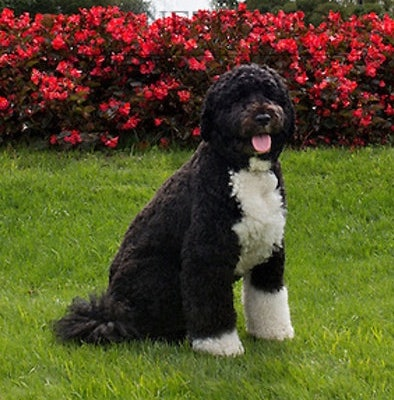

In [ ]:
# We can access any sample's filepath
Image.open(a_sample.filepath)

In [ ]:
# Use the dataset's query_similar method
similar_view = bo_dataset.sort_by_similarity(
  a_sample.id,
  brain_key="vgg16_imagenet_similarity",
  k=5,  # Return top k similar images
  reverse=False  # Most similar first
)

# We save the view so that we can retrieve it later
bo_dataset.save_view('most_similar_to_sample', similar_view)

## Creating a fine-tuned model based on the original VGG16 (transfer learning)

In [ ]:
# We take the embeddings produced by the original VGG16 model as features
# for a classifier that replaces the final layers of VGG16
# we keep this as illustration only
input_to_fine_tuned_model = nn.Sequential(model.features,
                                          model.avgpool,
                                          nn.Flatten())
input_to_fine_tuned_model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# this replaces the last layers of the original vgg16 model
model.classifier = nn.Sequential(nn.Linear(in_features=25088, out_features=4096),
                                 nn.ReLU(),
                                 nn.Linear(in_features=4096, out_features=1),
                                 )
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Day_25 (2nd Day of Computer Vision)

## Removing Duplicates

In [82]:
bo_dataset

Name:        bo-dataset
Media type:  image
Num samples: 172
Persistent:  False
Tags:        []
Sample fields:
    id:                        fiftyone.core.fields.ObjectIdField
    filepath:                  fiftyone.core.fields.StringField
    tags:                      fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                fiftyone.core.fields.DateTimeField
    last_modified_at:          fiftyone.core.fields.DateTimeField
    ground_truth:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    vgg16-imagenet-embeddings: fiftyone.core.fields.VectorField
    dup_type:                  fiftyone.core.fields.StringField
    dup_id:                    fiftyone.core.fields.StringField
    dup_dist:                  fiftyone.core.fields.FloatField

In [83]:
fob.compute_near_duplicates?

In [84]:
## Computing near duplicates with FiftyOne's Brain
# Calculate near duplicates
# https://docs.voxel51.com/brain.html#near-duplicates
dup_index = fob.compute_near_duplicates(
    bo_dataset,
    embeddings="vgg16-imagenet-embeddings", #change to the name that we use for vgg16 embeddings
    # may need to change this distance measure for non-default mode: thresh=0.02,
    threshold=0.1
    )

duplicates_view = dup_index.duplicates_view(
    type_field="dup_type",
    id_field="dup_id",
    dist_field="dup_dist",
    )

bo_dataset.save_view('thresh_0_point_1_view', duplicates_view)


Computing duplicate samples...


INFO:fiftyone.brain.similarity:Computing duplicate samples...


Duplicates computation complete


INFO:fiftyone.brain.similarity:Duplicates computation complete


ValueError: Saved view 'thresh_0_point_1_view' already exists

In [85]:
## Computing near duplicates with FiftyOne's Brain
# Calculate near duplicates
# https://docs.voxel51.com/brain.html#near-duplicates
dup_index = fob.compute_near_duplicates(
    bo_dataset,
    embeddings="vgg16-imagenet-embeddings", #change to the name that we use for vgg16 embeddings
    # may need to change this distance measure for non-default mode: thresh=0.02,
    threshold=0.2
    )

duplicates_view = dup_index.duplicates_view(
    type_field="dup_type",
    id_field="dup_id",
    dist_field="dup_dist",
    )

bo_dataset.save_view('thresh_0_point_2_view', duplicates_view)

Computing duplicate samples...


INFO:fiftyone.brain.similarity:Computing duplicate samples...


Duplicates computation complete


INFO:fiftyone.brain.similarity:Duplicates computation complete


ValueError: Saved view 'thresh_0_point_2_view' already exists

In [86]:
session.view = duplicates_view
print(session.url)

https://5151-gpu-t4-s-3iz5cf7onsgc9-b.us-west1-1.prod.colab.dev?polling=true


In [87]:
# Filter to only training samples
train_dups = duplicates_view.match_tags("train")

# Remove all near-duplicate samples from the training set
bo_clone = bo_dataset.clone()
#bo_dataset_dedup_set = bo_clone.remove_samples(train_dups.values("id"))

In [88]:
discard_view = bo_dataset.match_tags(tags="discard")
set_to_discard = set(discard_view.values('id'))
whole_set = set([id for id in bo_dataset.view().values('id')])
ids_to_use = whole_set - set_to_discard

In [89]:
# Create a view with the specified IDs
filtered_view = bo_dataset.select(list(ids_to_use))

# Save the view to the dataset
bo_dataset.save_view('deduplicated_dataset', filtered_view)

print(f"Created and saved view 'deduplicated_dataset' with {len(filtered_view)} samples.")

Created and saved view 'deduplicated_dataset' with 172 samples.


## Freezing layers from VGG16's convolutional base

In [92]:
# The weights and biases of the Linear Layers that we have added are trainable
for param in model.classifier.parameters():
    print(param.requires_grad)

True
True
True
True


## Creating a fine-tuned model based on the original VGG16 (transfer learning)

In [90]:
# We take the embeddings produced by the original VGG16 model as features
# for a classifier that replaces the final layers of VGG16
# we keep this as illustration only
input_to_fine_tuned_model = nn.Sequential(model.features,
                                           model.avgpool,
                                           nn.Flatten())
input_to_fine_tuned_model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [91]:
# this replaces the last layers of the original vgg16 model
model.classifier = nn.Sequential(nn.Linear(in_features=25088, out_features=4096),
                                           nn.ReLU(),
                                           nn.Linear(in_features=4096, out_features=1),)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Create `torch` datasets from FiftyOne views

In [99]:
import torch

# Custom PyTorch Dataset class for our binary classification data
class CustomTorchImageDataset(torch.utils.data.Dataset):
    def __init__(self, fiftyone_dataset,
                 image_transforms=None,
                 label_map=None,
                 gt_field="ground_truth"):
        self.fiftyone_dataset = fiftyone_dataset
        self.image_paths = self.fiftyone_dataset.values("filepath")
        self.str_labels = self.fiftyone_dataset.values(f"{gt_field}.label")
        self.image_transforms = image_transforms

        # Define the label map for 'bo' and 'not_bo'
        if label_map is None:
            self.label_map = {"not_bo": 0, "bo": 1}
        else:
            self.label_map = label_map

        print(f"CustomTorchImageDataset initialized with {len(self.image_paths)} samples.")
        print(f"Label map: {self.label_map}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            # Open image as RGB (default for PIL.Image.open)
            image = Image.open(image_path)
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            # Return a dummy tensor and an invalid label in case of error
            # The shape should match the expected input shape after transforms
            # Assuming transforms output (C, H, W)
            # You might need to adjust the dummy tensor shape based on your transforms
            return torch.randn(3, 224, 224), torch.tensor(-1, dtype=torch.long)


        if self.image_transforms:
            image = self.image_transforms(image)

        label_str = self.str_labels[idx]
        label_idx = self.label_map.get(label_str, -1)
        if label_idx == -1:
            print(f"Warning: Label '{label_str}' not in label_map for image {image_path}")
            # Return an invalid label if the label is not in the map
            label_idx = -1


        return image, torch.tensor(label_idx, dtype=torch.long)

## Define augmentations for the training set

In [100]:
train_augmentations = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    # Add random affine transformations: Shifting and Rotation
    transforms.RandomAffine(degrees=15,
                            translate=(0.1, 0.1),
                            scale=(1.0, 1.0), # no scale changes
                            interpolation=transforms.InterpolationMode.BILINEAR),
    # Standard scaler normalization for models pretrained on ImageNet data
    # These stats come from the mean and standard deviation of all training samples
    # inside the ImageNet1K dataset
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Create the FiftyOne views with our splits

In [101]:
train_view = filtered_view.match_tags('train')
validation_view = filtered_view.match_tags('validation')
test_view = filtered_view.match_tags('test')

In [104]:
# We can apply augmentation to the training set
train_torch_dataset = CustomTorchImageDataset(train_view, train_augmentations)
# Here validation and test sets have transformations that don't do augmentation
val_torch_dataset = CustomTorchImageDataset(validation_view, original_transformation)
test_torch_dataset = CustomTorchImageDataset(test_view, original_transformation)

CustomTorchImageDataset initialized with 106 samples.
Label map: {'not_bo': 0, 'bo': 1}
CustomTorchImageDataset initialized with 36 samples.
Label map: {'not_bo': 0, 'bo': 1}
CustomTorchImageDataset initialized with 30 samples.
Label map: {'not_bo': 0, 'bo': 1}


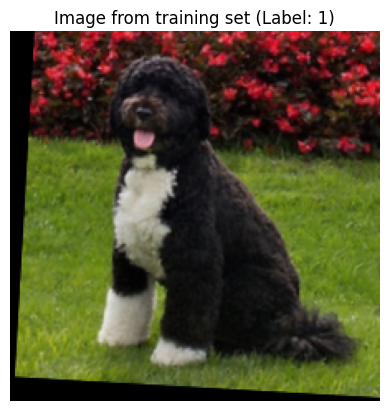

In [106]:
# Get an image and label from the dataset
image_tensor, label = train_torch_dataset[0]

# Define the denormalization transform
# These values are the inverse of the ImageNet normalization
denormalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Apply denormalization
denormalized_image_tensor = denormalize(image_tensor)

# Permute the dimensions from (C, H, W) to (H, W, C) for matplotlib
image_to_display = denormalized_image_tensor.permute(1, 2, 0)

# Plot the image
plt.imshow(image_to_display)
plt.title(f"Image from training set (Label: {label.item()})")
plt.axis('off')
plt.show()

In [107]:
val_torch_dataset[0]

(tensor([[[-0.7479, -0.7479, -0.7308,  ..., -0.2342, -0.2684, -0.3027],
          [-0.6623, -0.6623, -0.6452,  ..., -0.1999, -0.2342, -0.3027],
          [-0.6281, -0.5938, -0.5596,  ..., -0.1828, -0.2171, -0.2856],
          ...,
          [ 1.0331,  1.4098,  1.5982,  ...,  1.0159,  0.8789,  0.4166],
          [ 1.2043,  1.5125,  1.7180,  ...,  1.0502,  1.0331,  0.5022],
          [ 1.4440,  1.5125,  1.4269,  ...,  0.9474,  0.9817,  0.8276]],
 
         [[ 0.1176,  0.1176,  0.1352,  ...,  0.2402,  0.2052,  0.1702],
          [ 0.1702,  0.1702,  0.1702,  ...,  0.2752,  0.2402,  0.1702],
          [ 0.2052,  0.2052,  0.2227,  ...,  0.2927,  0.2577,  0.1877],
          ...,
          [ 1.4307,  1.7283,  1.8508,  ...,  1.1856,  1.1331,  0.8529],
          [ 1.5182,  1.7808,  1.9384,  ...,  1.2031,  1.2381,  0.9405],
          [ 1.6758,  1.7283,  1.6583,  ...,  1.1331,  1.1856,  1.1506]],
 
         [[-0.4450, -0.4101, -0.4101,  ...,  0.4788,  0.4439,  0.4091],
          [-0.4101, -0.3927,

## Define the loss function

In [108]:
# another option: nn.BCELoss() (BCE = binary cross entropy)
# We only use nn.BCELoss() if we include a Sigmoid activation at the end of the architecture
criterion = nn.BCEWithLogitsLoss() # (BCE = binary cross entropy)

## Create DataLoaders

In [109]:
from torch.utils.data import DataLoader as DataLoader

batch_size = 8

# Create DataLoaders
train_dataloader = DataLoader(
    train_torch_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffle training data
    num_workers=2, # Use multiple workers for faster data loading
    pin_memory=True # Speed-up data transfer from CPU to GPU
)

val_dataloader = DataLoader(
    val_torch_dataset,
    batch_size=batch_size,
    shuffle=False, # Do not shuffle validation data
    num_workers=2, # Use multiple workers for faster data loading
    pin_memory=True # Speed-up data transfer from CPU to GPU

)

## Define train and validation epochs

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [110]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [116]:
def train_epoch(model, train_loader):
  batch_losses = []
  model.train() # turn on DropOut and makes BatchNormalization compute running stats and use them
  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    # forward pass
    logits = model(images)

    # compute loss, we need to check that these dimensions agree
    loss_value = criterion(logits, labels.unsqueeze(1).float())
    return loss_value.item()
    break

In [117]:
from torch.optim import Adam, SGD
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [118]:
train_epoch(model, train_loader)

NameError: name 'train_loader' is not defined